# Get-Off-My-Lawn sanity-check walkthrough

The bandit wants to **approach and loiter** within a desired bandit-to-lady standoff band `[r_min_keep_m, r_max_keep_m]` while avoiding interception by any guard. The guard wants to **intercept** the bandit (catch event when within `catch_radius_m`) or **repel** it past the larger `keep_out_radius_m` shell. Inverting the LBG framing: where Lady-Bandit-Guard rewards the bandit for *reaching* the lady, Get-Off-My-Lawn rewards the bandit for *holding station* near her — a rendezvous-and-loiter task.

This notebook builds the scenario, runs a rollout, renders the trajectory, plots the rollout-time diagnostic with the loiter band shaded, and renders the 2D bandit-position reward surface.

For framework deep-dive see `examples/workflow_3d_rtn.ipynb`. For the reward formula and knob reference see `docs/games/get-off-my-lawn.md`.

## 0. Device setup (Apple Silicon safety guard)

`orbitalgym` enables `jax_enable_x64` at import for orbit precision, but Apple's MLX backend rejects float64. If `jax-mps` is installed, JAX picks MPS as the default device and the first array allocation crashes. We pin the default to CPU before the `import orbitalgym` below; opt into MPS per-call via `jax.default_device(jax.devices('mps')[0])`. See `examples/running_on_mps.ipynb` for the full story.

In [1]:
import importlib.metadata
import os

try:
    importlib.metadata.distribution('jax-mps')
    os.environ.setdefault('JAX_PLATFORMS', 'cpu,mps')
    os.environ.setdefault('JAX_DEFAULT_DEVICE', 'cpu')
except importlib.metadata.PackageNotFoundError:
    os.environ.setdefault('JAX_PLATFORMS', 'cpu')

In [2]:
%load_ext autoreload
%autoreload 2

import jax
import matplotlib.pyplot as plt

from orbitalgym import OrbitalGymEnv, rollout
from orbitalgym.env.types import BySide
from orbitalgym.games import make_get_off_my_lawn
from orbitalgym.policies import ZeroControl
from orbitalgym.viz import (
    plot_get_off_my_lawn_diagnostic,
    plot_get_off_my_lawn_position_sweep,
    plot_reward_diagnostic,
    plot_reward_position_sweep,
    plot_rollout_panels,
    plot_rollout_rewards,
)

print('JAX', jax.__version__, '| default backend:', jax.default_backend())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Platform 'mps' is experimental and not all JAX functionality may be correctly supported!


JAX 0.10.0 | default backend: cpu


## 1. Build the scenario

`make_get_off_my_lawn` exposes four game-specific knobs (`r_min_keep_m`, `r_max_keep_m`, `catch_radius_m`, `keep_out_radius_m`) plus the standard scenario knobs. The `GetOffMyLawn` game owns these knobs and wires `GetOffMyLawnReward` + `GetOffMyLawnTermination` onto the cfg automatically — no `setattr` overrides required. `__post_init__` enforces `r_min_keep_m < r_max_keep_m < keep_out_radius_m` so misconfiguration fails fast at construction.

In [3]:
cfg = make_get_off_my_lawn(
    r_min_keep_m=100.0,
    r_max_keep_m=500.0,
    catch_radius_m=50.0,
    keep_out_radius_m=1500.0,
    n_guards=1,
    n_bandits=1,
    dt=10.0,
    max_horizon_s=3000.0,
    seed=0,
)
print(f"max_steps:           {cfg.max_steps}")
print(f"r_min_keep_m:        {cfg.game.r_min_keep_m} m")
print(f"r_max_keep_m:        {cfg.game.r_max_keep_m} m")
print(f"catch_radius_m:      {cfg.game.catch_radius_m} m")
print(f"keep_out_radius_m:   {cfg.game.keep_out_radius_m} m")
print(f"reward_fn:           {type(cfg.reward_fn).__name__}")
print(f"termination_fn:      {type(cfg.termination_fn).__name__}")
print(f"reference orbit:     {cfg.reference_orbit.position_eci[:3]} m")

max_steps:           300
r_min_keep_m:        100.0 m
r_max_keep_m:        500.0 m
catch_radius_m:      50.0 m
keep_out_radius_m:   1500.0 m
reward_fn:           GetOffMyLawnReward
termination_fn:      GetOffMyLawnTermination
reference orbit:     [7000000.       0.       0.] m


## 2. Construct env and run two rollouts (zero-control, two seeds)

Under zero control neither side maneuvers. The bandit drifts on its IC relative orbit (default ~600 m radial ellipse on the opposite side from the guard), so it stays comfortably inside the keep-out shell but outside the loiter band — the dense band penalty accumulates and the guard never closes. This is the *uncontrolled equilibrium* for the game; solving it requires a controlled bandit policy.

In [4]:
env = OrbitalGymEnv(cfg)
guard_policy = ZeroControl(n_vehicles=cfg.n_guards, command_cls=env.guard_command_cls)
bandit_policy = ZeroControl(n_vehicles=cfg.n_bandits, command_cls=env.bandit_command_cls)
init_ps = BySide(
    guard=lambda c, s, k: None,
    bandit=lambda c, s, k: None,
)
key1, key2 = jax.random.split(jax.random.PRNGKey(42), 2)
traj1 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key1, n_steps=cfg.max_steps)
traj2 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key2, n_steps=cfg.max_steps)
print(f"rollout 1 bandit return:  {float(traj1.sides.bandit.reward.sum()):.2f}")
print(f"rollout 1 guard return:   {float(traj1.sides.guard.reward.sum()):.2f}")
print(f"rollout 2 bandit return:  {float(traj2.sides.bandit.reward.sum()):.2f}")
print(f"rollout 2 guard return:   {float(traj2.sides.guard.reward.sum()):.2f}")

rollout 1 bandit return:  115.53
rollout 1 guard return:   -483.52
rollout 2 bandit return:  68.71
rollout 2 guard return:   -436.58


## 3. Trajectory + reward over time

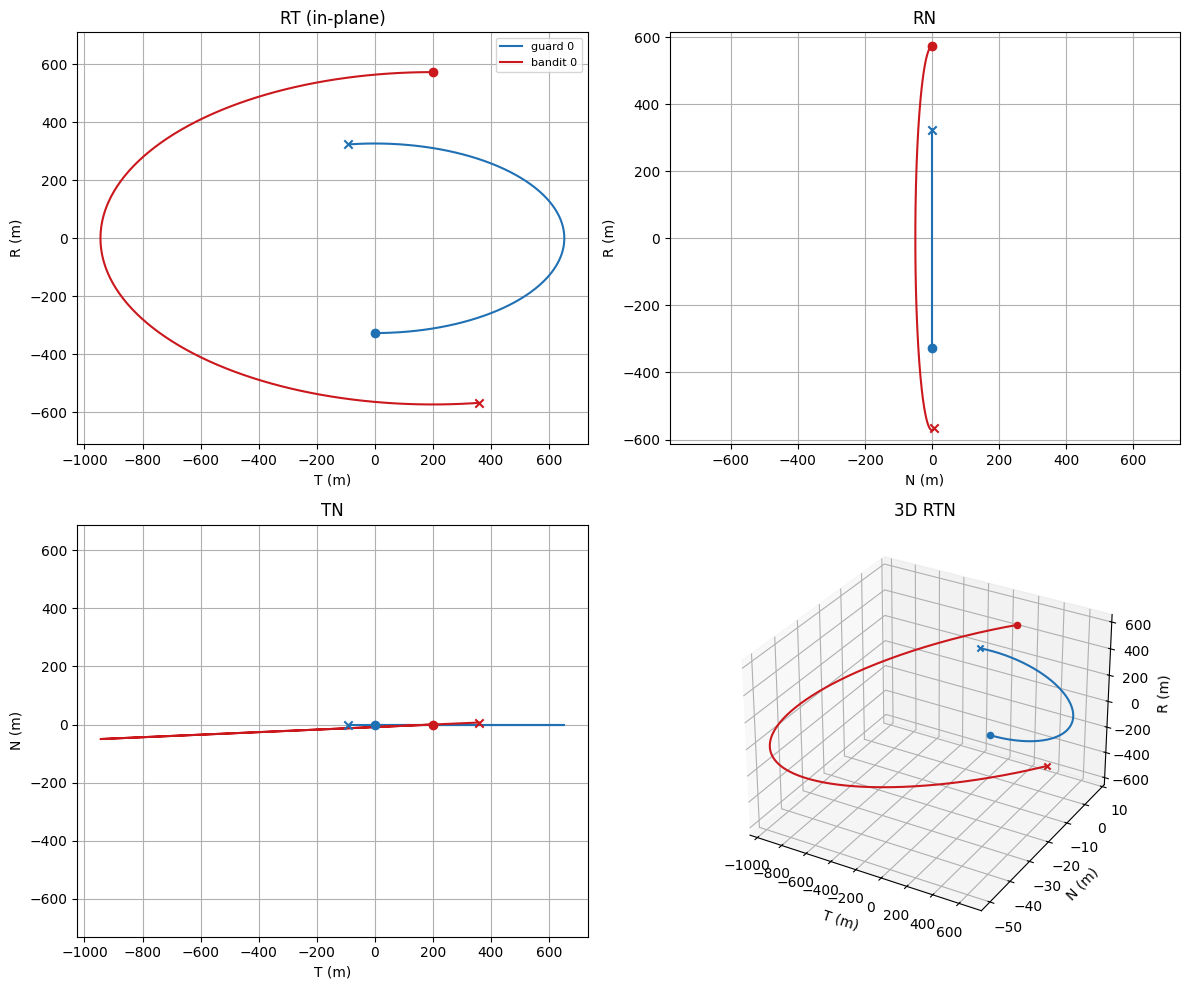

In [5]:
fig = plot_rollout_panels(traj1)
plt.show()

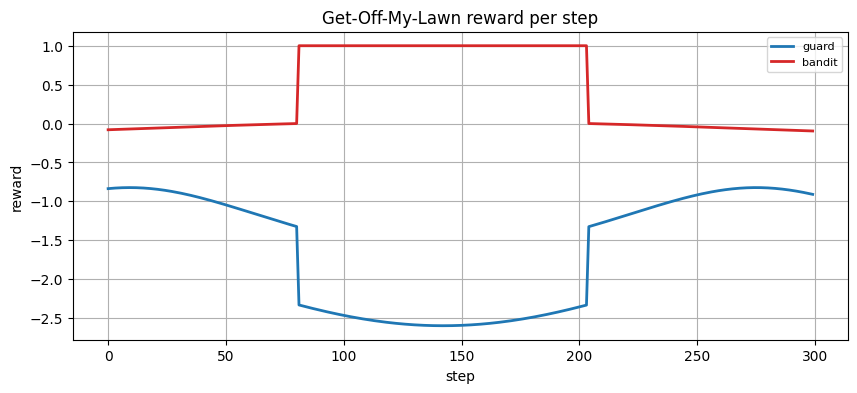

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_rollout_rewards(traj1, ax=ax)
ax.set_title("Get-Off-My-Lawn reward per step")
plt.show()

## 4. Game-specific rollout diagnostic

Three panels:

- **Top:** per-bandit distance to the lady, with the loiter band shaded green and the keep-out shell drawn as a red dashed line. Inside the green band the bandit earns the loiter bonus; beyond the dashed line the episode terminates with a guard pushout win.
- **Middle:** minimum guard-bandit distance with the `catch_radius_m` line. When this drops below the line the guard catches the bandit and the episode ends with a guard win.
- **Bottom:** bandit and guard reward over time.

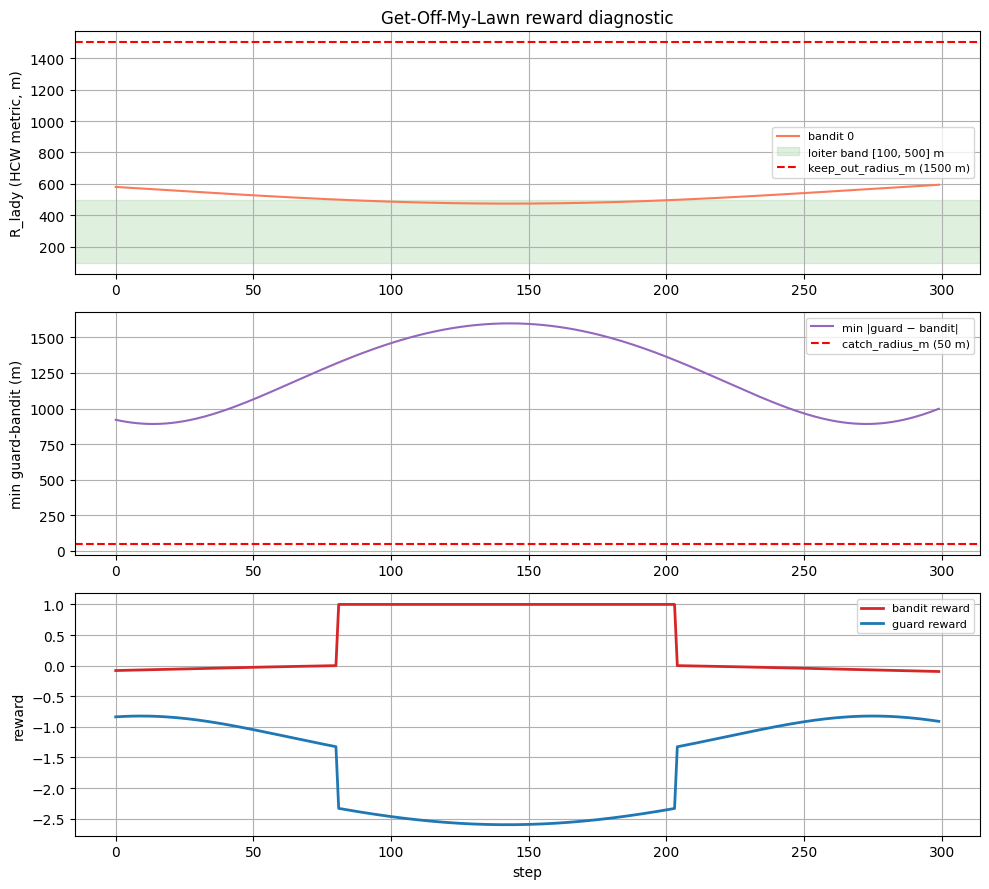

In [7]:
fig = plot_reward_diagnostic(traj1, cfg)
plt.show()

## 5. 2D position-sweep surface

Bandit-position sweep with the guard pinned at the reference-orbit origin (RTN=0). Inside the loiter band (annulus around the origin) the surface is at the loiter ceiling; outside the band the surface decays linearly with band-distance; right at the origin the catch event drives the surface deep negative. The annular peak around the origin is the bandit's target standoff geometry.

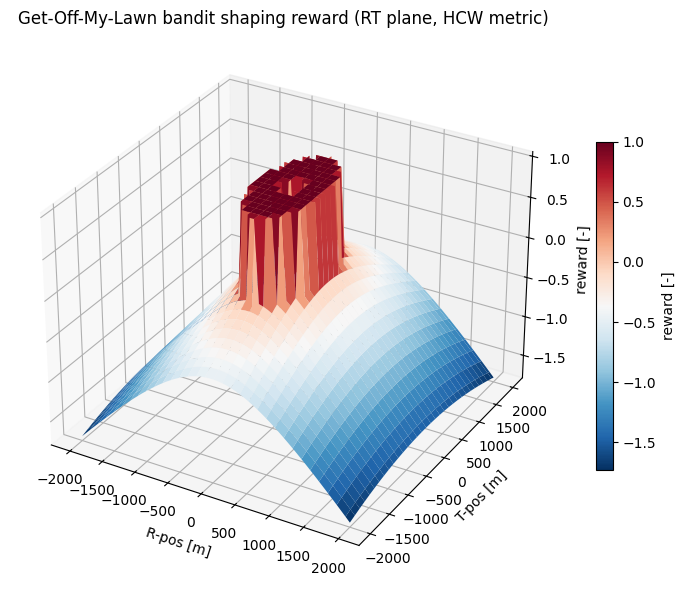

In [8]:
fig = plot_reward_position_sweep(cfg, grid_extent_m=2000.0, grid_steps=64, axis_pair="rt")
plt.show()

## 6. Where to next

- Framework deep-dive: `examples/workflow_3d_rtn.ipynb`
- Game guide: `docs/games/get-off-my-lawn.md`
- Other games: `examples/games/lady_bandit_guard.ipynb`, `pursuit_evasion.ipynb`, `sun_blocking.ipynb`, `observation_blocking.ipynb`